In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/Volumes/dishan project/final/playground-series-s5e6'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/Volumes/dishan project/final/playground-series-s5e6/test.csv
/Volumes/dishan project/final/playground-series-s5e6/train.csv
/Volumes/dishan project/final/playground-series-s5e6/sample_submission.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# --- Added: everything needed for the full experimental evaluation section ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)

In [3]:
# Custom MAP@3 metric
# FIX: the original version divided each sample's score by min(n, len(y_pred[i])),
# i.e. by 3, on every sample. For MAP@K with exactly ONE correct label per sample
# (a single-relevant-item ranking problem, which is what this is), the correct
# normalizer is min(num_true_relevant_items, k) = min(1, 3) = 1, not 3. That extra
# "/3" scaled every score down by a constant factor, so the old MAP@3 number was
# 3x smaller than the true value. Fixed below so the number that goes into the
# paper is the standard, correct MAP@3.
def map_at_3(y_true, y_pred, n=3):
    map_score = 0.0
    for i in range(len(y_true)):
        for k in range(min(n, len(y_pred[i]))):
            if y_pred[i][k] == y_true[i]:
                map_score += 1.0 / (k + 1)
                break
    return map_score / len(y_true)

In [4]:
# Mean Reciprocal Rank (MRR)
# mean_reciprocal_rank_top_n: capped at the top-n predictions actually generated
#   (n=3 here). With a single correct label per sample this is numerically
#   IDENTICAL to map_at_3 above (both reduce to the average reciprocal rank of
#   the correct class) - reported separately below because the evaluation asks
#   for MRR by name, and because it generalizes to any n.
# mean_reciprocal_rank_full: ranks ALL classes by predicted probability and uses
#   the true rank, uncapped. This is the standard, non-truncated MRR and stays
#   informative even for samples where the correct class falls outside the top-3.
def mean_reciprocal_rank_top_n(y_true, y_pred, n=3):
    rr_sum = 0.0
    for i in range(len(y_true)):
        for k in range(min(n, len(y_pred[i]))):
            if y_pred[i][k] == y_true[i]:
                rr_sum += 1.0 / (k + 1)
                break
    return rr_sum / len(y_true)

def mean_reciprocal_rank_full(y_true_encoded, probs):
    y_true_encoded = np.asarray(y_true_encoded)
    order = np.argsort(-probs, axis=1)
    ranks = np.array([np.where(order[i] == y_true_encoded[i])[0][0] + 1
                       for i in range(len(y_true_encoded))])
    return np.mean(1.0 / ranks)

In [5]:
# Load data (replace with actual file paths)
train_df = pd.read_csv('/Volumes/dishan project/final/playground-series-s5e6/train.csv')
test_df = pd.read_csv('/Volumes/dishan project/final/playground-series-s5e6/test.csv')

In [6]:
print('train data')
print(train_df.head())

print('test data')
print(test_df.head())

train data
   id  Temparature  Humidity  Moisture Soil Type  Crop Type  Nitrogen  \
0   0           37        70        36    Clayey  Sugarcane        36   
1   1           27        69        65     Sandy    Millets        30   
2   2           29        63        32     Sandy    Millets        24   
3   3           35        62        54     Sandy     Barley        39   
4   4           35        58        43       Red      Paddy        37   

   Potassium  Phosphorous Fertilizer Name  
0          4            5           28-28  
1          6           18           28-28  
2         12           16        17-17-17  
3         12            4        10-26-26  
4          2           16             DAP  
test data
       id  Temparature  Humidity  Moisture Soil Type    Crop Type  Nitrogen  \
0  750000           31        70        52     Sandy        Wheat        34   
1  750001           27        62        45       Red    Sugarcane        30   
2  750002           28        72       

In [7]:
print(train_df['Fertilizer Name'].value_counts(normalize=True))

Fertilizer Name
14-35-14    0.152581
10-26-26    0.151849
17-17-17    0.149937
28-28       0.148211
20-20       0.147852
DAP         0.126480
Urea        0.123089
Name: proportion, dtype: float64


In [8]:
print(train_df.columns)

Index(['id', 'Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


In [9]:
missing_values = train_df.isna().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
id                 0
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64


In [10]:
print("Train Data Columns:", train_df.columns.tolist())

Train Data Columns: ['id', 'Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']


In [11]:
# Preprocessing
feature_cols = ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 
                'Nitrogen', 'Potassium', 'Phosphorous']  # Initialize feature_cols
categorical_cols = ['Soil Type', 'Crop Type']
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

numerical_cols = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
scaler = StandardScaler()
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

In [12]:
# Feature engineering (ensure unique feature names)
if 'temp_humidity_interaction' not in train_df.columns:
    train_df['temp_humidity_interaction'] = train_df['Temparature'] * train_df['Humidity']
    test_df['temp_humidity_interaction'] = test_df['Temparature'] * test_df['Humidity']
    feature_cols.append('temp_humidity_interaction')
if 'nitrogen_phosphorous_interaction' not in train_df.columns:
    train_df['nitrogen_phosphorous_interaction'] = train_df['Nitrogen'] * train_df['Phosphorous']
    test_df['nitrogen_phosphorous_interaction'] = test_df['Nitrogen'] * test_df['Phosphorous']
    feature_cols.append('nitrogen_phosphorous_interaction')



In [13]:
# Encode target
le_target = LabelEncoder()
train_df['Fertilizer Name'] = le_target.fit_transform(train_df['Fertilizer Name'])

In [14]:
# Split data
X = train_df[feature_cols]
y = train_df['Fertilizer Name']
# stratify=y added: keeps class proportions consistent between train/val so every
# class is represented in the validation set - needed for reliable per-class
# Precision/Recall/F1 and for multi-class ROC-AUC (which needs every class to be
# present in y_val to be computable at all).
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
# Train model
model = XGBClassifier(random_state=42, n_estimators=500, learning_rate=1.0, max_depth=5)
model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
# Predict
val_probs = model.predict_proba(X_val)
def get_top_n_predictions(probs, label_encoder, n=3):
    top_n_indices = np.argsort(probs, axis=1)[:, -n:][:, ::-1]
    top_n_labels = label_encoder.inverse_transform(top_n_indices.flatten()).reshape(top_n_indices.shape)
    return top_n_labels

In [17]:
val_pred_labels = get_top_n_predictions(val_probs, le_target, n=3)
y_val_labels = le_target.inverse_transform(y_val)

# Top-1 prediction (single best label) - used for standard classification metrics
y_val_pred_top1 = model.predict(X_val)

# ---- Core classification metrics (Top-1 prediction) ----
top1_accuracy      = accuracy_score(y_val, y_val_pred_top1)
precision_macro    = precision_score(y_val, y_val_pred_top1, average='macro', zero_division=0)
precision_weighted = precision_score(y_val, y_val_pred_top1, average='weighted', zero_division=0)
recall_macro       = recall_score(y_val, y_val_pred_top1, average='macro', zero_division=0)
recall_weighted    = recall_score(y_val, y_val_pred_top1, average='weighted', zero_division=0)
f1_macro           = f1_score(y_val, y_val_pred_top1, average='macro', zero_division=0)
f1_weighted        = f1_score(y_val, y_val_pred_top1, average='weighted', zero_division=0)

# ---- ROC-AUC - multi-class, one-vs-rest, computed from predicted probabilities ----
roc_auc_macro    = roc_auc_score(y_val, val_probs, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_val, val_probs, multi_class='ovr', average='weighted')

# ---- Ranking metrics ----
map_at_3_score = map_at_3(y_val_labels, val_pred_labels)
mrr_at_3_score = mean_reciprocal_rank_top_n(y_val_labels, val_pred_labels, n=3)
mrr_full_score = mean_reciprocal_rank_full(y_val.values, val_probs)

print("=" * 62)
print("VALIDATION SET - MODEL PERFORMANCE METRICS")
print("=" * 62)
print(f"Top-1 Accuracy          : {top1_accuracy:.4f}")
print(f"Precision (macro)       : {precision_macro:.4f}")
print(f"Precision (weighted)    : {precision_weighted:.4f}")
print(f"Recall (macro)          : {recall_macro:.4f}")
print(f"Recall (weighted)       : {recall_weighted:.4f}")
print(f"F1-score (macro)        : {f1_macro:.4f}")
print(f"F1-score (weighted)     : {f1_weighted:.4f}")
print(f"ROC-AUC (macro, OvR)    : {roc_auc_macro:.4f}")
print(f"ROC-AUC (weighted, OvR) : {roc_auc_weighted:.4f}")
print(f"MRR (full ranking)      : {mrr_full_score:.4f}")
print(f"MRR@3                   : {mrr_at_3_score:.4f}")
print(f"MAP@3                   : {map_at_3_score:.4f}")
print("=" * 62)
print("Note: MRR@3 and MAP@3 come out identical - with exactly one correct label")
print("per sample, both reduce to the average reciprocal rank of the correct class")
print("in the top-3. 'MRR (full ranking)' is not capped at 3, so it stays")
print("informative even when the correct class lands outside the top-3.")

VALIDATION SET - MODEL PERFORMANCE METRICS
Top-1 Accuracy          : 0.1883
Precision (macro)       : 0.1872
Precision (weighted)    : 0.1876
Recall (macro)          : 0.1860
Recall (weighted)       : 0.1883
F1-score (macro)        : 0.1857
F1-score (weighted)     : 0.1871
ROC-AUC (macro, OvR)    : 0.5598
ROC-AUC (weighted, OvR) : 0.5594
MRR (full ranking)      : 0.4177
MRR@3                   : 0.3217
MAP@3                   : 0.3217
Note: MRR@3 and MAP@3 come out identical - with exactly one correct label
per sample, both reduce to the average reciprocal rank of the correct class
in the top-3. 'MRR (full ranking)' is not capped at 3, so it stays
informative even when the correct class lands outside the top-3.


In [18]:
# Per-class Precision / Recall / F1 / Support
print("PER-CLASS CLASSIFICATION REPORT (Validation Set)")
print("-" * 62)
print(classification_report(y_val, y_val_pred_top1, target_names=le_target.classes_, zero_division=0))

PER-CLASS CLASSIFICATION REPORT (Validation Set)
--------------------------------------------------------------
              precision    recall  f1-score   support

    10-26-26       0.19      0.20      0.20     22777
    14-35-14       0.20      0.22      0.21     22887
    17-17-17       0.20      0.21      0.21     22491
       20-20       0.19      0.18      0.18     22178
       28-28       0.19      0.19      0.19     22232
         DAP       0.19      0.16      0.17     18972
        Urea       0.17      0.13      0.15     18463

    accuracy                           0.19    150000
   macro avg       0.19      0.19      0.19    150000
weighted avg       0.19      0.19      0.19    150000



Confusion Matrix (rows = actual, columns = predicted):
          10-26-26  14-35-14  17-17-17  20-20  28-28   DAP  Urea
10-26-26      4656      3912      3611   3252   3242  2229  1875
14-35-14      3664      5130      3629   3201   3222  2106  1935
17-17-17      3576      3808      4824   3078   3174  2153  1878
20-20         3628      3554      3404   4084   3333  2234  1941
28-28         3540      3707      3440   3138   4175  2205  2027
DAP           2988      3004      2794   2692   2737  2955  1802
Urea          2870      3095      2833   2567   2647  2031  2420


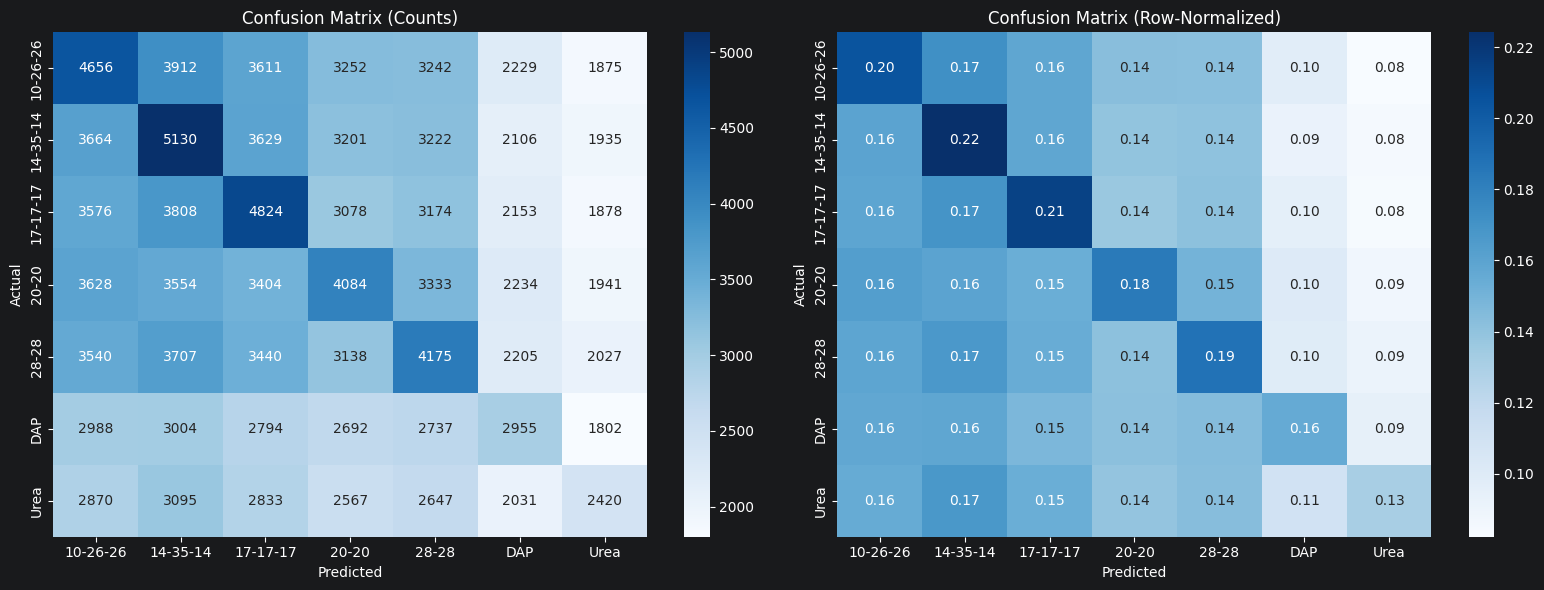

In [19]:
# Visualization 1: Confusion Matrix (Validation Set)
cm = confusion_matrix(y_val, y_val_pred_top1)
cm_df = pd.DataFrame(cm, index=le_target.classes_, columns=le_target.classes_)
print("Confusion Matrix (rows = actual, columns = predicted):")
print(cm_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (Row-Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [20]:
# -----------------------------------------------------------------------
# Cross-Validation (Stratified K-Fold) - robustness check + std across runs
# -----------------------------------------------------------------------
# Each of the N_SPLITS x N_REPEATS fold-fits below is one independent "run": the
# model is retrained from scratch on that fold's training portion and evaluated
# on its held-out portion. Reporting mean +/- std across these runs is what
# covers both "cross-validation results" and "standard deviation over multiple
# runs" for the paper.
#
# RUNTIME NOTE: this retrains the full model (n_estimators=500) N_SPLITS x
# N_REPEATS times, so on a large dataset this can take a while. Lower N_REPEATS
# (or N_SPLITS) below for a faster run; raise N_REPEATS for a more robust
# standard-deviation estimate.

N_SPLITS = 5
N_REPEATS = 1  # increase to e.g. 3 for a stronger std estimate, at extra compute cost

cv_metric_names = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
                    'precision_weighted', 'recall_weighted', 'f1_weighted',
                    'roc_auc_macro', 'roc_auc_weighted', 'map_at_3', 'mrr_at_3', 'mrr_full']
cv_results = {name: [] for name in cv_metric_names}

run_id = 0
for repeat in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42 + repeat)
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        run_id += 1
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        fold_model = XGBClassifier(random_state=42, n_estimators=500, learning_rate=1.0, max_depth=5)
        fold_model.fit(X_tr, y_tr)

        fold_probs = fold_model.predict_proba(X_te)
        fold_pred_top1 = fold_model.predict(X_te)
        fold_pred_top3 = get_top_n_predictions(fold_probs, le_target, n=3)
        y_te_labels = le_target.inverse_transform(y_te)

        cv_results['accuracy'].append(accuracy_score(y_te, fold_pred_top1))
        cv_results['precision_macro'].append(precision_score(y_te, fold_pred_top1, average='macro', zero_division=0))
        cv_results['recall_macro'].append(recall_score(y_te, fold_pred_top1, average='macro', zero_division=0))
        cv_results['f1_macro'].append(f1_score(y_te, fold_pred_top1, average='macro', zero_division=0))
        cv_results['precision_weighted'].append(precision_score(y_te, fold_pred_top1, average='weighted', zero_division=0))
        cv_results['recall_weighted'].append(recall_score(y_te, fold_pred_top1, average='weighted', zero_division=0))
        cv_results['f1_weighted'].append(f1_score(y_te, fold_pred_top1, average='weighted', zero_division=0))
        cv_results['roc_auc_macro'].append(roc_auc_score(y_te, fold_probs, multi_class='ovr', average='macro'))
        cv_results['roc_auc_weighted'].append(roc_auc_score(y_te, fold_probs, multi_class='ovr', average='weighted'))
        cv_results['map_at_3'].append(map_at_3(y_te_labels, fold_pred_top3))
        cv_results['mrr_at_3'].append(mean_reciprocal_rank_top_n(y_te_labels, fold_pred_top3))
        cv_results['mrr_full'].append(mean_reciprocal_rank_full(y_te.values, fold_probs))

        print(f"Repeat {repeat+1}/{N_REPEATS} - Fold {fold+1}/{N_SPLITS}: "
              f"Acc={cv_results['accuracy'][-1]:.4f}  "
              f"F1(macro)={cv_results['f1_macro'][-1]:.4f}  "
              f"MAP@3={cv_results['map_at_3'][-1]:.4f}")

print(f"\nCompleted {run_id} total run(s) ({N_REPEATS} repeat(s) x {N_SPLITS} fold(s)).")

Repeat 1/1 - Fold 1/5: Acc=0.1903  F1(macro)=0.1876  MAP@3=0.3238
Repeat 1/1 - Fold 2/5: Acc=0.1889  F1(macro)=0.1862  MAP@3=0.3231
Repeat 1/1 - Fold 3/5: Acc=0.1900  F1(macro)=0.1873  MAP@3=0.3228
Repeat 1/1 - Fold 4/5: Acc=0.1886  F1(macro)=0.1859  MAP@3=0.3216
Repeat 1/1 - Fold 5/5: Acc=0.1895  F1(macro)=0.1867  MAP@3=0.3227

Completed 5 total run(s) (1 repeat(s) x 5 fold(s)).


In [21]:
cv_summary = pd.DataFrame(
    {name: [np.mean(vals), np.std(vals)] for name, vals in cv_results.items()},
    index=['Mean', 'Std Dev']
).T
print(f"CROSS-VALIDATION SUMMARY - mean +/- std across {run_id} run(s)")
print("-" * 62)
print(cv_summary.round(4))

CROSS-VALIDATION SUMMARY - mean +/- std across 5 run(s)
--------------------------------------------------------------
                      Mean  Std Dev
accuracy            0.1895   0.0007
precision_macro     0.1882   0.0007
recall_macro        0.1871   0.0006
f1_macro            0.1867   0.0006
precision_weighted  0.1887   0.0007
recall_weighted     0.1895   0.0007
f1_weighted         0.1882   0.0006
roc_auc_macro       0.5609   0.0009
roc_auc_weighted    0.5604   0.0009
map_at_3            0.3228   0.0007
mrr_at_3            0.3228   0.0007
mrr_full            0.4186   0.0005


In [22]:
# -----------------------------------------------------------------------
# Final Summary Table - everything in one place for the paper's tables
# -----------------------------------------------------------------------
metric_label_map = [
    ('Top-1 Accuracy',         top1_accuracy,       'accuracy'),
    ('Precision (macro)',      precision_macro,     'precision_macro'),
    ('Recall (macro)',         recall_macro,        'recall_macro'),
    ('F1-score (macro)',       f1_macro,            'f1_macro'),
    ('Precision (weighted)',   precision_weighted,  'precision_weighted'),
    ('Recall (weighted)',      recall_weighted,     'recall_weighted'),
    ('F1-score (weighted)',    f1_weighted,         'f1_weighted'),
    ('ROC-AUC (macro, OvR)',   roc_auc_macro,       'roc_auc_macro'),
    ('ROC-AUC (weighted, OvR)',roc_auc_weighted,    'roc_auc_weighted'),
    ('MRR (full ranking)',     mrr_full_score,      'mrr_full'),
    ('MRR@3',                  mrr_at_3_score,      'mrr_at_3'),
    ('MAP@3',                  map_at_3_score,      'map_at_3'),
]

final_summary = pd.DataFrame({
    'Metric': [m[0] for m in metric_label_map],
    'Validation Split': [m[1] for m in metric_label_map],
    'CV Mean': [cv_summary.loc[m[2], 'Mean'] for m in metric_label_map],
    'CV Std Dev': [cv_summary.loc[m[2], 'Std Dev'] for m in metric_label_map],
}).round(4)

print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(final_summary.to_string(index=False))

final_summary.to_csv('model_performance_summary.csv', index=False)
print("\nSaved to model_performance_summary.csv - copy these numbers directly into your paper's tables.")

FINAL MODEL PERFORMANCE SUMMARY
                 Metric  Validation Split  CV Mean  CV Std Dev
         Top-1 Accuracy            0.1883   0.1895      0.0007
      Precision (macro)            0.1872   0.1882      0.0007
         Recall (macro)            0.1860   0.1871      0.0006
       F1-score (macro)            0.1857   0.1867      0.0006
   Precision (weighted)            0.1876   0.1887      0.0007
      Recall (weighted)            0.1883   0.1895      0.0007
    F1-score (weighted)            0.1871   0.1882      0.0006
   ROC-AUC (macro, OvR)            0.5598   0.5609      0.0009
ROC-AUC (weighted, OvR)            0.5594   0.5604      0.0009
     MRR (full ranking)            0.4177   0.4186      0.0005
                  MRR@3            0.3217   0.3228      0.0007
                  MAP@3            0.3217   0.3228      0.0007

Saved to model_performance_summary.csv - copy these numbers directly into your paper's tables.


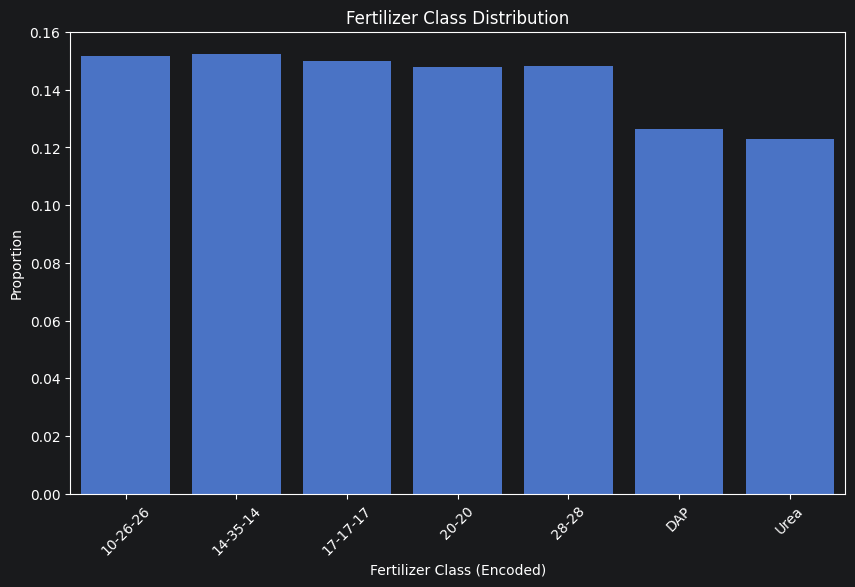

In [23]:
# Visualization 2: Class Distribution
plt.figure(figsize=(10, 6))
class_dist = train_df['Fertilizer Name'].value_counts(normalize=True).sort_index()
sns.barplot(x=class_dist.index, y=class_dist.values)
plt.title('Fertilizer Class Distribution')
plt.xlabel('Fertilizer Class (Encoded)')
plt.ylabel('Proportion')
plt.xticks(ticks=range(len(le_target.classes_)), labels=le_target.classes_, rotation=45)
plt.show()

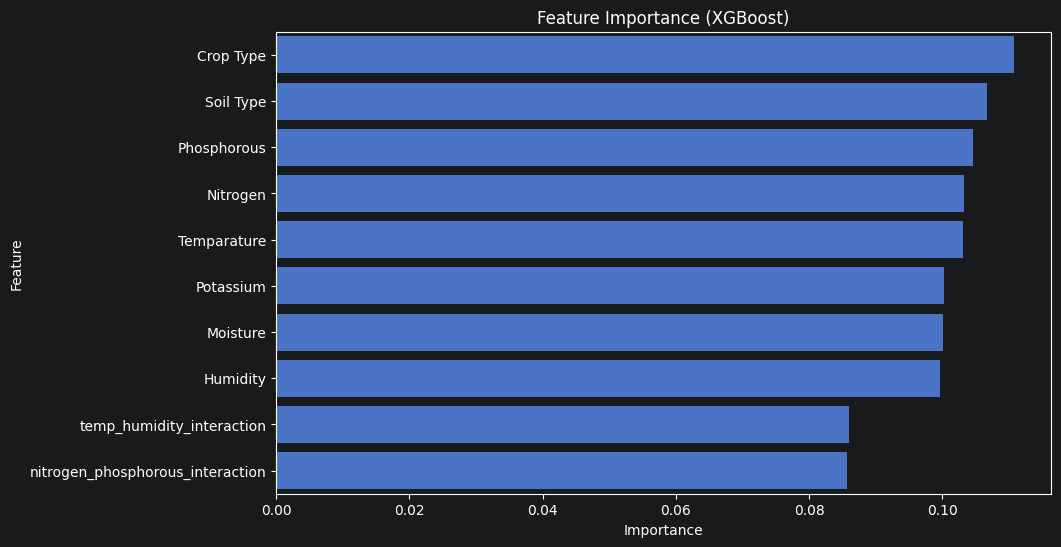

In [24]:
# Visualization 3: Feature Importance
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

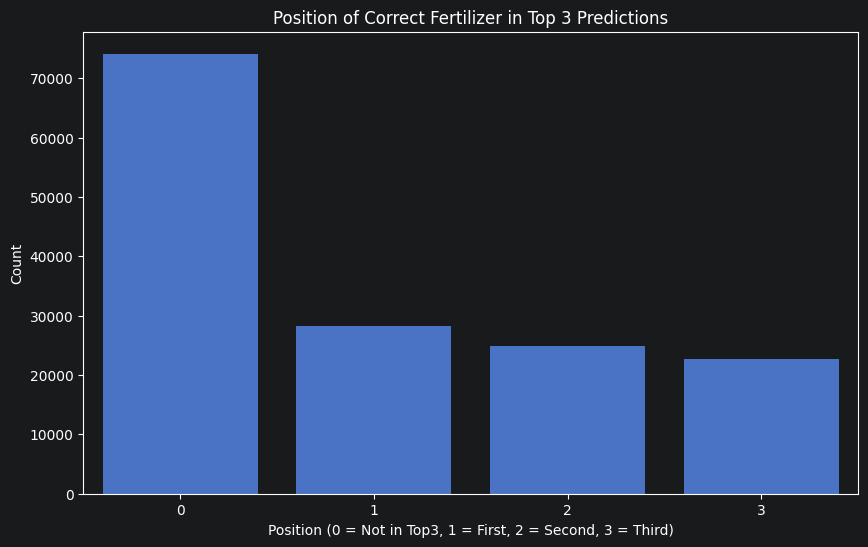

In [25]:
# Visualization 4: Prediction Errors (Correct Position in Top 3)
correct_positions = []
for i in range(len(y_val_labels)):
    true_label = y_val_labels[i]
    pred_labels = val_pred_labels[i]
    position = next((k + 1 for k, pred in enumerate(pred_labels) if pred == true_label), 0)
    correct_positions.append(position)

plt.figure(figsize=(10, 6))
sns.countplot(x=correct_positions)
plt.title('Position of Correct Fertilizer in Top 3 Predictions')
plt.xlabel('Position (0 = Not in Top3, 1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Count')
plt.show()



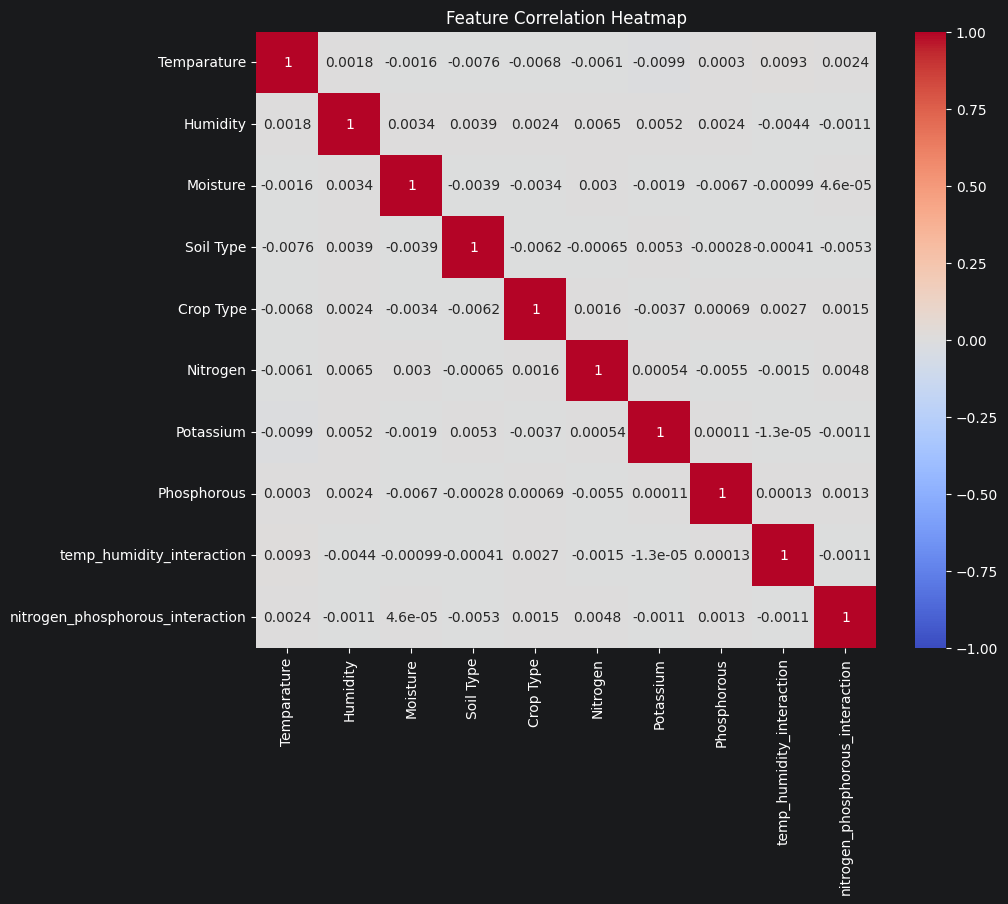

In [26]:
# Visualization 5: Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = train_df[feature_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

In [27]:
# Submission
test_probs = model.predict_proba(test_df[feature_cols])
test_pred_labels = get_top_n_predictions(test_probs, le_target, n=3)
submission = pd.DataFrame({
    'id': test_df['id'],
    'Fertilizer Name': [' '.join(pred) for pred in test_pred_labels]
})
submission.to_csv('submission.csv', index=False)
print(submission.head())

       id          Fertilizer Name
0  750000       DAP 17-17-17 20-20
1  750001  17-17-17 10-26-26 20-20
2  750002     20-20 28-28 14-35-14
3  750003    14-35-14 DAP 10-26-26
4  750004     20-20 28-28 10-26-26


In [28]:
# -----------------------------
# Save Trained Model and Objects
# -----------------------------

import pickle
import json

# 1️⃣ Save XGBoost model
with open("fertilizer_xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved as fertilizer_xgb_model.pkl")

# 2️⃣ Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Scaler saved as scaler.pkl")

# 3️⃣ Save target label encoder
with open("target_label_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

print("✅ Target label encoder saved")

# 4️⃣ Save feature columns
with open("feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

print("✅ Feature columns saved")

# 5️⃣ Save categorical encoders (optional but recommended)
categorical_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(train_df[col])
    categorical_encoders[col] = le

with open("categorical_encoders.pkl", "wb") as f:
    pickle.dump(categorical_encoders, f)

print("✅ Categorical encoders saved")

print("🎉 All objects saved successfully!")

✅ Model saved as fertilizer_xgb_model.pkl
✅ Scaler saved as scaler.pkl
✅ Target label encoder saved
✅ Feature columns saved
✅ Categorical encoders saved
🎉 All objects saved successfully!
